<a href="https://colab.research.google.com/github/bmwelu12/ML_WorldCup_repo/blob/main/wc2026_model_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Does a 2022-trained team-strength model predict the 2026 World Cup?

This notebook builds a simple team-strength model from **2022 World Cup tactical data (FAR / VAEP style metrics)**,
falls back to **FIFA World Ranking points** for teams that weren't at the 2022 tournament, and grades its predictions
against the **actual 2026 World Cup knockout results** (Round of 32 through Quarterfinals).

**The honest framing:** this tests whether *2022 tactical identity* generalizes four years forward — not current form.



Introduction, model objective

## 1. Import Libraries and Load Data

Section: Libraries, Data

In [7]:
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt

far_csv = """team,avg_atk_far,avg_def_far,total_team_far
Argentina,0.07052293052141671,0.01465857360551953,14.324782741264254
Australia,0.07113578143841129,0.021063056187631584,6.89258411199738
Belgium,0.017464314142057253,0.014764997732199001,2.7405986009437786
Brazil,0.10570049055056517,0.02582493960794349,14.331372960348212
Cameroon,0.12457253804465568,0.022733564157823048,7.250346998995688
Canada,0.015550557423724763,0.02146176018700609,2.254987963771912
Costa Rica,0.0452144700581755,0.06182857540754539,5.775855047347571
Croatia,0.10349415964755715,0.019141573853855953,13.319275315338604
Denmark,0.06066352693650571,0.025890980391346415,5.19787335725821
Ecuador,0.0614192277326115,0.030886541691812333,5.05347995233975
England,0.19461161160005913,-0.00099778568885983,12.186538906132785
France,0.09384664859654464,0.014713172721098807,17.46092844349613
Germany,0.1651895356384107,0.02243481131086387,8.990603420939056
Ghana,0.0998794330497346,0.009589106698623765,5.829692034787552
Iran,0.09986094247802058,0.03258948370097915,6.875359022304574
Japan,0.11156026422644673,0.01910517352759454,7.5791642236621595
Mexico,0.04314449737689329,0.013908320915388786,5.033350076340284
Morocco,0.0640471461466185,0.028374646633062647,14.166069780158828
Netherlands,0.12300112908177008,0.01595421423701082,12.442197318284299
Poland,0.027094738700559923,0.024299114231088628,4.256195772147395
Portugal,0.15712347657372858,-0.001169956931252164,11.221369046798127
Qatar,0.07157411764094783,0.02593637585301072,3.4162649542133465
Saudi Arabia,0.06609362780498343,0.03661882335023816,4.9794213398644676
Senegal,0.10786171698360877,0.013750302095566037,7.586568112094124
Serbia,0.13126259470943064,0.013768977828219254,7.701249103691888
South Korea,0.05065483756880861,0.021791440866867292,6.487980399175697
Spain,0.12828869352044286,0.01436206935872624,10.25620577125353
Switzerland,0.06347217412249156,0.028194138046823598,7.848439086898658
Tunisia,0.06382528661570552,0.018140701588960258,4.216247234999237
United States,0.08362238046723545,0.034347700969235284,6.762591440909286
Uruguay,0.06286362689155219,0.022974209329995873,4.4838748670932205
Wales,0.028759399461584276,0.04408888010760111,3.184521557735973
"""
fifa_csv = """team,fifa_points
Argentina,1877
Spain,1874
France,1870
England,1828
Portugal,1767
Brazil,1765
Morocco,1755
Netherlands,1753
Belgium,1742
Germany,1735
Croatia,1714
Italy,1704
Colombia,1698
Mexico,1687
Senegal,1684
Uruguay,1673
USA,1671
Japan,1661
Switzerland,1650
Iran,1619
Denmark,1619
Turkiye,1605
Ecuador,1598
Austria,1597
South Korea,1591
Nigeria,1585
Australia,1579
Algeria,1571
Egypt,1562
Canada,1559
Norway,1557
Ukraine,1549
Ivory Coast,1540
Panama,1539
Russia,1529
Poland,1526
Wales,1516
Sweden,1509
Hungary,1506
Czechia,1505
Paraguay,1505
Scotland,1503
Serbia,1502
Cameroon,1481
Tunisia,1476
DR Congo,1474
Slovakia,1473
Greece,1473
Venezuela,1469
Uzbekistan,1458
Chile,1458
Peru,1457
Costa Rica,1456
Romania,1455
Mali,1455
Qatar,1450
Iraq,1446
Ireland,1441
Slovenia,1441
South Africa,1428
Saudi Arabia,1423
Burkina Faso,1406
Jordan,1387
Bosnia and Herzegovina,1387
Honduras,1378
Albania,1376
Cape Verde,1371
United Arab Emirates,1370
North Macedonia,1369
Northern Ireland,1365
Jamaica,1357
Georgia,1355
Ghana,1346
Iceland,1342
Finland,1341
Israel,1333
Bolivia,1325
Kosovo,1319
Oman,1306
Montenegro,1301
Guinea,1295
Curacao,1294
Haiti,1293
Syria,1283
New Zealand,1275
"""
results_csv = """round,match_no,team_a,team_b,winner,decided_by
R32,73,South Africa,Canada,Canada,normal
R32,76,Brazil,Japan,Brazil,normal
R32,74,Germany,Paraguay,Paraguay,penalties
R32,75,Netherlands,Morocco,Morocco,penalties
R32,78,Ivory Coast,Norway,Norway,normal
R32,77,France,Sweden,France,normal
R32,79,Mexico,Ecuador,Mexico,normal
R32,80,England,DR Congo,England,normal
R32,82,Belgium,Senegal,Belgium,normal
R32,81,USA,Bosnia and Herzegovina,USA,normal
R32,84,Spain,Austria,Spain,normal
R32,83,Portugal,Croatia,Portugal,normal
R32,85,Switzerland,Algeria,Switzerland,normal
R32,88,Australia,Egypt,Egypt,penalties
R32,86,Argentina,Cape Verde,Argentina,normal
R32,87,Colombia,Ghana,Colombia,normal
R16,90,Canada,Morocco,Morocco,normal
R16,89,Paraguay,France,France,normal
R16,91,Brazil,Norway,Norway,normal
R16,92,Mexico,England,England,normal
R16,93,Portugal,Spain,Spain,normal
R16,94,USA,Belgium,Belgium,normal
R16,95,Argentina,Egypt,Argentina,normal
R16,96,Switzerland,Colombia,Switzerland,penalties
QF,97,France,Morocco,France,normal
QF,98,Spain,Belgium,Spain,normal
QF,99,Norway,England,England,normal
QF,100,Argentina,Switzerland,Argentina,normal
"""

far = pd.read_csv(StringIO(far_csv))
fifa = pd.read_csv(StringIO(fifa_csv))
results = pd.read_csv(StringIO(results_csv))

print(far.shape, fifa.shape, results.shape)
far.head()


(32, 4) (85, 2) (28, 6)


,team,avg_atk_far,avg_def_far,total_team_far
0,Argentina,0.070523,0.014659,14.324783
1,Australia,0.071136,0.021063,6.892584
2,Belgium,0.017464,0.014765,2.740599
3,Brazil,0.105700,0.025825,14.331373
4,Cameroon,0.124573,0.022734,7.250347


Load raw data

## 2. Normalize team names

The three sources spell some countries differently (`United States` vs `USA`, `IR Iran` vs `Iran`, `Cabo Verde` vs `Cape Verde`, etc). Reconcile them before joining.

Section: Normalize Names

In [8]:
name_map = {
    "United States": "USA",
    "Türkiye": "Turkiye",
}
far["team"] = far["team"].replace(name_map)

fifa_name_map = {
    "IR Iran": "Iran",
    "Cabo Verde": "Cape Verde",
    "Cote d'Ivoire": "Ivory Coast",
    "Curacao": "Curaçao",
}
fifa["team"] = fifa["team"].replace(fifa_name_map)


Standardize team names

## 3. Standardize Team Names

Section: Build Strength

## 3. Build a unified team-strength score

Both sources are z-scored within themselves so they sit on a comparable scale. **2022 FAR is the primary signal** for any team that played in 2022; **FIFA ranking points are the fallback** for teams that didn't (debutants like Cape Verde, Uzbekistan, Jordan, Curaçao, or teams that simply didn't qualify in 2022, like Colombia, Norway, or Czechia).

Section: Unified Strength

In [9]:
far["far_z"] = (far["total_team_far"] - far["total_team_far"].mean()) / far["total_team_far"].std()
fifa["fifa_z"] = (fifa["fifa_points"] - fifa["fifa_points"].mean()) / fifa["fifa_points"].std()

far_lookup = dict(zip(far["team"], far["far_z"]))
fifa_lookup = dict(zip(fifa["team"], fifa["fifa_z"]))

def team_strength(team):
    if team in far_lookup:
        return far_lookup[team], "2022 FAR (primary)"
    elif team in fifa_lookup:
        return fifa_lookup[team], "FIFA ranking (fallback)"
    else:
        return None, "MISSING"


Calculate base strength

## 4. Define Win Probability Model

Section: Win Probability

## 4. Win probability model

A simple logistic function on the rating differential (Elo-style). `SCALE` controls how decisive a given rating gap is — it's set qualitatively here, not fit to data, and would be the first thing to tune with more matches.

Section: Win Probability

In [10]:
SCALE = 1.3

def win_prob(rating_a, rating_b):
    diff = rating_a - rating_b
    return 1 / (1 + np.exp(-diff / SCALE))


Define win probability

## 5. Evaluate Model Against Known Matches

Section: Evaluate Model

## 5. Predict every knockout match, then grade against reality

Section: Evaluate Predictions

In [11]:
rows = []
missing_teams = set()
for _, r in results.iterrows():
    a, b, winner = r["team_a"], r["team_b"], r["winner"]
    rating_a, source_a = team_strength(a)
    rating_b, source_b = team_strength(b)
    if rating_a is None:
        missing_teams.add(a); continue
    if rating_b is None:
        missing_teams.add(b); continue

    p_a = win_prob(rating_a, rating_b)
    predicted_winner = a if p_a >= 0.5 else b
    predicted_prob = p_a if predicted_winner == a else (1 - p_a)
    correct = predicted_winner == winner
    outcome_a = 1 if winner == a else 0
    brier = (p_a - outcome_a) ** 2

    rows.append({
        "round": r["round"], "match": f"{a} vs {b}",
        "rating_source_a": source_a, "rating_source_b": source_b,
        "model_pick": predicted_winner, "model_confidence": round(predicted_prob, 3),
        "actual_winner": winner, "decided_by": r["decided_by"],
        "correct": correct, "brier": round(brier, 4),
    })

eval_df = pd.DataFrame(rows)
print(f"Missing teams (excluded): {missing_teams}")
print(f"Matches evaluated: {len(eval_df)}")
print(f"Accuracy: {eval_df['correct'].mean():.1%}")
print(f"Avg Brier score: {eval_df['brier'].mean():.4f}  (0 = perfect, 0.25 = coin flip)")
eval_df.groupby("round")["correct"].agg(["mean", "count"])


Missing teams (excluded): set()
Matches evaluated: 28
Accuracy: 64.3%
Avg Brier score: 0.2011  (0 = perfect, 0.25 = coin flip)


,mean,count
round,,
QF,1.000,4
R16,0.500,8
R32,0.625,16


Evaluate model predictions

## 6. Analyze Model's Incorrect Predictions (Upsets)

Section: Analyze Upsets

## 6. Where the model was wrong

The most useful part of a retrodiction like this isn't the accuracy number — it's *which* misses are explainable. A model giving Brazil a 74% chance against Norway, then getting it wrong, tells a much clearer story than a vague \"the model isn't perfect.\"

Section: Model Errors

In [12]:
upsets = eval_df[~eval_df["correct"]][["round", "match", "model_pick", "model_confidence", "actual_winner", "decided_by"]]
upsets.sort_values("model_confidence", ascending=False)


,round,match,model_pick,model_confidence,actual_winner,decided_by
18,R16,Brazil vs Norway,Brazil,0.742,Norway,normal
8,R32,Belgium vs Senegal,Senegal,0.719,Belgium,normal
23,R16,Switzerland vs Colombia,Colombia,0.713,Switzerland,penalties
21,R16,USA vs Belgium,USA,0.686,Belgium,normal
0,R32,South Africa vs Canada,South Africa,0.656,Canada,normal
11,R32,Portugal vs Croatia,Croatia,0.601,Portugal,normal
2,R32,Germany vs Paraguay,Germany,0.569,Paraguay,penalties
12,R32,Switzerland vs Algeria,Algeria,0.568,Switzerland,normal
20,R16,Portugal vs Spain,Portugal,0.547,Spain,normal
6,R32,Mexico vs Ecuador,Ecuador,0.501,Mexico,normal


Identify model upsets

## 7. Visualize Model Confidence and Correctness

Section: Visualize Confidence

## 7. Visualize confidence vs. correctness

Section: Visualize Confidence

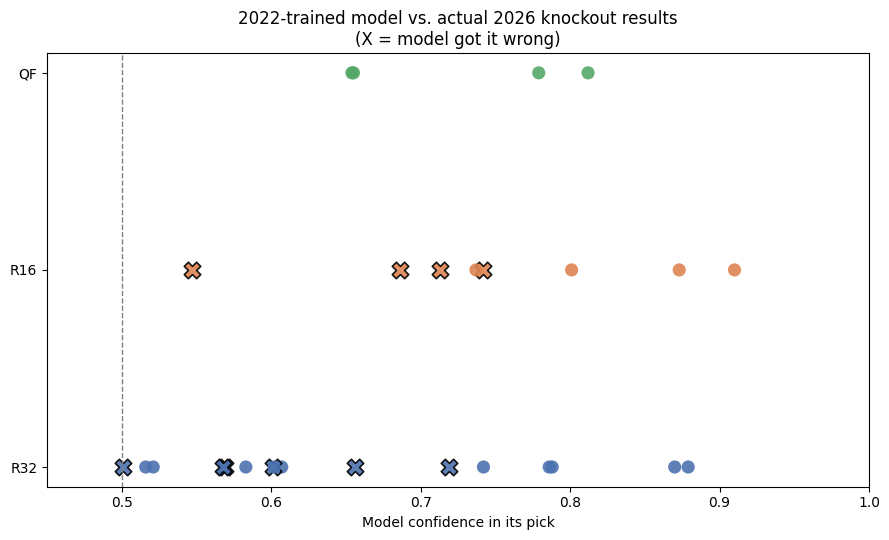

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {"R32": "#4C72B0", "R16": "#DD8452", "QF": "#55A868"}
markers = {True: "o", False: "X"}

for _, row in eval_df.iterrows():
    ax.scatter(
        row["model_confidence"], row["round"],
        c=colors[row["round"]], marker=markers[row["correct"]],
        s=140 if not row["correct"] else 90,
        edgecolors="black" if not row["correct"] else "none",
        linewidths=1.2, alpha=0.9,
    )

ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Model confidence in its pick")
ax.set_title("2022-trained model vs. actual 2026 knockout results\n(X = model got it wrong)")
ax.set_xlim(0.45, 1.0)
plt.tight_layout()
plt.show()


Visualize model performance

## 8. Integrated Model with Z-scores and Brier Score Optimization

Section: Integrated Model

In [14]:
import pandas as pd
import numpy as np
from io import StringIO
from scipy.optimize import minimize_scalar

groups_csv = """team_a,team_b,score_a,score_b
Mexico,South Africa,2,0
South Korea,Czechia,2,1
Canada,Bosnia and Herzegovina,1,1
Qatar,Switzerland,1,1
USA,Paraguay,4,1
Australia,Turkiye,2,0
Brazil,Morocco,1,1
Haiti,Scotland,0,1
Germany,Curaçao,7,1
Ivory Coast,Ecuador,1,0
Netherlands,Japan,2,2
Sweden,Tunisia,5,1
Belgium,Egypt,1,1
Iran,New Zealand,2,2
Spain,Cape Verde,0,0
Saudi Arabia,Uruguay,1,1
France,Senegal,3,1
Iraq,Norway,1,4
Argentina,Algeria,3,0
Austria,Jordan,3,1
Portugal,DR Congo,1,1
Uzbekistan,Colombia,1,3
England,Croatia,4,2
Ghana,Panama,1,0
Czechia,South Africa,1,1
Mexico,South Korea,1,0
Switzerland,Bosnia and Herzegovina,4,1
Canada,Qatar,6,0
Scotland,Morocco,0,1
Brazil,Haiti,3,0
USA,Australia,2,0
Turkiye,Paraguay,0,1
Germany,Ivory Coast,2,1
Ecuador,Curaçao,0,0
Netherlands,Sweden,5,1
Tunisia,Japan,0,4
Belgium,Iran,0,0
New Zealand,Egypt,1,3
Spain,Saudi Arabia,4,0
Uruguay,Cape Verde,2,2
France,Iraq,3,0
Norway,Senegal,3,2
Argentina,Austria,2,0
Jordan,Algeria,1,2
Portugal,Uzbekistan,5,0
Colombia,DR Congo,1,0
England,Ghana,0,0
Panama,Croatia,0,1
Czechia,Mexico,0,3
South Africa,South Korea,1,0
Switzerland,Canada,2,1
Bosnia and Herzegovina,Qatar,3,1
Scotland,Brazil,0,3
Morocco,Haiti,4,2
Turkiye,USA,3,2
Paraguay,Australia,0,0
Curaçao,Ivory Coast,0,2
Ecuador,Germany,2,1
Japan,Sweden,1,1
Tunisia,Netherlands,1,3
Egypt,Iran,1,1
New Zealand,Belgium,1,5
Cape Verde,Saudi Arabia,0,0
Uruguay,Spain,0,1
Norway,France,1,4
Senegal,Iraq,5,0
Algeria,Austria,3,3
Jordan,Argentina,1,3
Colombia,Portugal,0,0
DR Congo,Uzbekistan,3,1
Panama,England,0,2
Croatia,Ghana,2,1
"""

far = pd.read_csv(StringIO(far_csv))
fifa = pd.read_csv(StringIO(fifa_csv))
results = pd.read_csv(StringIO(results_csv))
groups = pd.read_csv(StringIO(groups_csv))

# ---- 2. Normalize team names across sources ----
far["team"] = far["team"].replace({"United States": "USA", "Türkiye": "Turkiye"})
fifa["team"] = fifa["team"].replace({
    "IR Iran": "Iran", "Cabo Verde": "Cape Verde",
    "Cote d'Ivoire": "Ivory Coast", "Curacao": "Curaçao",
})

# ---- 3. Base team strength: 2022 FAR (primary) or FIFA ranking (fallback) ----
far["far_z"] = (far["total_team_far"] - far["total_team_far"].mean()) / far["total_team_far"].std()
fifa["fifa_z"] = (fifa["fifa_points"] - fifa["fifa_points"].mean()) / fifa["fifa_points"].std()
far_lookup = dict(zip(far["team"], far["far_z"]))
fifa_lookup = dict(zip(fifa["team"], fifa["fifa_z"]))

def team_strength(team):
    if team in far_lookup:
        return far_lookup[team], "2022 FAR (primary)"
    elif team in fifa_lookup:
        return fifa_lookup[team], "FIFA ranking (fallback)"
    return None, "MISSING"

# ---- 4. Recent-form signal: 2026 group-stage goal difference ----
long_a = groups.rename(columns={"team_a": "team", "score_a": "gf", "score_b": "ga"})[["team", "gf", "ga"]]
long_b = groups.rename(columns={"team_b": "team", "score_b": "gf", "score_a": "ga"})[["team", "gf", "ga"]]
gd = pd.concat([long_a, long_b], ignore_index=True).groupby("team")[["gf", "ga"]].sum()
gd["goal_diff"] = gd["gf"] - gd["ga"]
gd = gd.reset_index()
gd["form_z"] = (gd["goal_diff"] - gd["goal_diff"].mean()) / gd["goal_diff"].std()
form_lookup = dict(zip(gd["team"], gd["form_z"]))

FORM_WEIGHT = 0.3

def blended_strength(team):
    base, source = team_strength(team)
    if base is None:
        return None, source
    if team in form_lookup:
        return (1 - FORM_WEIGHT) * base + FORM_WEIGHT * form_lookup[team], source + " + 2026 form"
    return base, source

# ---- 5. Fit SCALE by minimizing Brier score over known matches ----
def brier_for_scale(scale, strength_fn=blended_strength):
    total, n = 0.0, 0
    for _, r in results.iterrows():
        a, b, winner = r["team_a"], r["team_b"], r["winner"]
        rating_a, _ = strength_fn(a)
        rating_b, _ = strength_fn(b)
        if rating_a is None or rating_b is None:
            continue
        p_a = 1 / (1 + np.exp(-(rating_a - rating_b) / scale))
        total += (p_a - (1 if winner == a else 0)) ** 2
        n += 1
    return total / n

FITTED_SCALE = minimize_scalar(brier_for_scale, bounds=(0.1, 5.0), method="bounded").x

# ---- 6. Grade every known match ----
rows = []
for _, r in results.iterrows():
    a, b, winner = r["team_a"], r["team_b"], r["winner"]
    rating_a, source_a = blended_strength(a)
    rating_b, source_b = blended_strength(b)
    if rating_a is None or rating_b is None:
        continue
    p_a = 1 / (1 + np.exp(-(rating_a - rating_b) / FITTED_SCALE))
    pick = a if p_a >= 0.5 else b
    conf = p_a if pick == a else 1 - p_a
    rows.append({"round": r["round"], "match": f"{a} vs {b}", "pick": pick,
                 "confidence": round(conf, 3), "actual": winner, "correct": pick == winner})

eval_df = pd.DataFrame(rows)
print(f"Fitted SCALE: {FITTED_SCALE:.3f}")
print(f"Accuracy: {eval_df['correct'].mean():.1%}  |  Brier: {brier_for_scale(FITTED_SCALE):.4f}")

# ---- 7. Predict matches not yet played ----
for a, b in [("France", "Spain"), ("England", "Argentina")]:
    rating_a, _ = blended_strength(a)
    rating_b, _ = blended_strength(b)
    p_a = 1 / (1 + np.exp(-(rating_a - rating_b) / FITTED_SCALE))
    pick = a if p_a >= 0.5 else b
    conf = p_a if pick == a else 1 - p_a
    print(f"{a} vs {b}: model picks {pick} ({conf:.1%})")

Fitted SCALE: 0.949
Accuracy: 71.4%  |  Brier: 0.1833
France vs Spain: model picks France (82.4%)
England vs Argentina: model picks Argentina (64.6%)


Define integrated model

## 9. Player Continuity Data

Section: Player Continuity

In [21]:
import pandas as pd
import numpy as np
from io import StringIO

continuity_csv = """player,team,position_group,minutes,n_matches,xg_per90,xa_per90,goals_per90,prog_pass_per90,prog_carry_per90,tackles_per90,interceptions_per90,pressures_per90,team_2026,attacking_output,defensive_output,role_type
Lionel Andrés Messi Cuccittini,Argentina,ST,720,7,0.949831153125,0.305690612875,1.125,11.125,7.0,0.5,0.0,11.125,Argentina,1.256,0.5,attacker
Rodrigo Javier De Paul,Argentina,CM,624,7,0.0822176698557692,0.0353727602884615,0.0,12.98076923076923,5.913461538461538,1.1538461538461535,1.4423076923076923,16.009615384615383,Argentina,0.118,2.596,midfielder
Marcus Rashford,England,W,170,5,0.7319571855882353,0.0,1.5882352941176472,3.1764705882352944,3.1764705882352944,1.05882335294117647,0.5294117647058824,9.0,England,0.732,1.588,attacker
Harry Kane,England,ST,415,5,0.5055137225783133,0.2941886472289157,0.4337349397590362,4.337349397590362,2.168674698795181,0.4337349397590362,0.0,6.722891566265061,England,0.8,0.434,attacker
Jude Bellingham,England,CM,435,5,0.1740530428965517,0.0499289197241379,0.2068965517241379,9.93103448275862,3.724137931034483,1.4482758620689655,0.8275862068965518,14.482758620689657,England,0.224,2.276,midfielder
Kylian Mbappé Lottin,France,W,642,7,0.7032829734112149,0.1171565097196261,1.2616822429906542,4.485981308411215,7.710280373831775,0.0,0.1401869158878504,5.186915887850467,France,0.82,0.14,attacker
Daniel Olmo Carvajal,Spain,W,383,4,0.2547531316527415,0.0763240147519582,0.2349869451697128,3.0548302872062663,5.169712793733681,0.9399477806788512,0.7049608355091384,10.809399477806789,Spain,0.331,1.645,attacker
Rodrigo Hernández Cascante,Spain,CB,406,4,0.0012519413866995,0.0372647163546798,0.0,38.793103448275865,16.182266009852217,0.6650246305418719,0.8866995073891626,4.211822660098522,Spain,0.039,1.552,defender
"""
continuity = pd.read_csv(StringIO(continuity_csv))
continuity

,player,team,position_group,minutes,n_matches,xg_per90,xa_per90,goals_per90,prog_pass_per90,prog_carry_per90,tackles_per90,interceptions_per90,pressures_per90,team_2026,attacking_output,defensive_output,role_type
0,Lionel Andrés Messi Cuccittini,Argentina,ST,720,7,0.949831,0.305691,1.125000,11.125000,7.000000,0.500000,0.000000,11.125000,Argentina,1.256,0.500,attacker
1,Rodrigo Javier De Paul,Argentina,CM,624,7,0.082218,0.035373,0.000000,12.980769,5.913462,1.153846,1.442308,16.009615,Argentina,0.118,2.596,midfielder
2,Marcus Rashford,England,W,170,5,0.731957,0.000000,1.588235,3.176471,3.176471,1.058823,0.529412,9.000000,England,0.732,1.588,attacker
3,Harry Kane,England,ST,415,5,0.505514,0.294189,0.433735,4.337349,2.168675,0.433735,0.000000,6.722892,England,0.800,0.434,attacker
4,Jude Bellingham,England,CM,435,5,0.174053,0.049929,0.206897,9.931034,3.724138,1.448276,0.827586,14.482759,England,0.224,2.276,midfielder
5,Kylian Mbappé Lottin,France,W,642,7,0.703283,0.117157,1.261682,4.485981,7.710280,0.000000,0.140187,5.186916,France,0.820,0.140,attacker
6,Daniel Olmo Carvajal,Spain,W,383,4,0.254753,0.076324,0.234987,3.054830,5.169713,0.939948,0.704961,10.809399,Spain,0.331,1.645,attacker
7,Rodrigo Hernández Cascante,Spain,CB,406,4,0.001252,0.037265,0.000000,38.793103,16.182266,0.665025,0.886700,4.211823,Spain,0.039,1.552,defender


Load continuity data

## 10. Attacker-only Continuity and Z-scores

Section: Continuity Z-scores

In [22]:
# @title Default title text
import pandas as pd
import numpy as np
from io import StringIO

continuity_csv = """player,team,position_group,minutes,n_matches,xg_per90,xa_per90,goals_per90,prog_pass_per90,prog_carry_per90,tackles_per90,interceptions_per90,pressures_per90,team_2026,attacking_output,defensive_output,role_type
Lionel Andrés Messi Cuccittini,Argentina,ST,720,7,0.949831153125,0.305690612875,1.125,11.125,7.0,0.5,0.0,11.125,Argentina,1.256,0.5,attacker
Rodrigo Javier De Paul,Argentina,CM,624,7,0.0822176698557692,0.0353727602884615,0.0,12.98076923076923,5.913461538461538,1.1538461538461535,1.4423076923076923,16.009615384615383,Argentina,0.118,2.596,midfielder
Marcus Rashford,England,W,170,5,0.7319571855882353,0.0,1.5882352941176472,3.1764705882352944,3.1764705882352944,1.0588235294117647,0.5294117647058824,9.0,England,0.732,1.588,attacker
Harry Kane,England,ST,415,5,0.5055137225783133,0.2941886472289157,0.4337349397590362,4.337349397590362,2.168674698795181,0.4337349397590362,0.0,6.722891566265061,England,0.8,0.434,attacker
Jude Bellingham,England,CM,435,5,0.1740530428965517,0.0499289197241379,0.2068965517241379,9.93103448275862,3.724137931034483,1.4482758620689655,0.8275862068965518,14.482758620689657,England,0.224,2.276,midfielder
Kylian Mbappé Lottin,France,W,642,7,0.7032829734112149,0.1171565097196261,1.2616822429906542,4.485981308411215,7.710280373831775,0.0,0.1401869158878504,5.186915887850467,France,0.82,0.14,attacker
Daniel Olmo Carvajal,Spain,W,383,4,0.2547531316527415,0.0763240147519582,0.2349869451697128,3.0548302872062663,5.169712793733681,0.9399477806788512,0.7049608355091384,10.809399477806789,Spain,0.331,1.645,attacker
Rodrigo Hernández Cascante,Spain,CB,406,4,0.0012519413866995,0.0372647163546798,0.0,38.793103448275865,16.182266009852217,0.6650246305418719,0.8866995073891626,4.211822660098522,Spain,0.039,1.552,defender
"""
continuity = pd.read_csv(StringIO(continuity_csv))
continuity

,player,team,position_group,minutes,n_matches,xg_per90,xa_per90,goals_per90,prog_pass_per90,prog_carry_per90,tackles_per90,interceptions_per90,pressures_per90,team_2026,attacking_output,defensive_output,role_type
0,Lionel Andrés Messi Cuccittini,Argentina,ST,720,7,0.949831,0.305691,1.125000,11.125000,7.000000,0.500000,0.000000,11.125000,Argentina,1.256,0.500,attacker
1,Rodrigo Javier De Paul,Argentina,CM,624,7,0.082218,0.035373,0.000000,12.980769,5.913462,1.153846,1.442308,16.009615,Argentina,0.118,2.596,midfielder
2,Marcus Rashford,England,W,170,5,0.731957,0.000000,1.588235,3.176471,3.176471,1.058824,0.529412,9.000000,England,0.732,1.588,attacker
3,Harry Kane,England,ST,415,5,0.505514,0.294189,0.433735,4.337349,2.168675,0.433735,0.000000,6.722892,England,0.800,0.434,attacker
4,Jude Bellingham,England,CM,435,5,0.174053,0.049929,0.206897,9.931034,3.724138,1.448276,0.827586,14.482759,England,0.224,2.276,midfielder
5,Kylian Mbappé Lottin,France,W,642,7,0.703283,0.117157,1.261682,4.485981,7.710280,0.000000,0.140187,5.186916,France,0.820,0.140,attacker
6,Daniel Olmo Carvajal,Spain,W,383,4,0.254753,0.076324,0.234987,3.054830,5.169713,0.939948,0.704961,10.809399,Spain,0.331,1.645,attacker
7,Rodrigo Hernández Cascante,Spain,CB,406,4,0.001252,0.037265,0.000000,38.793103,16.182266,0.665025,0.886700,4.211823,Spain,0.039,1.552,defender


Load continuity data

In [17]:
attackers = continuity[continuity["role_type"] == "attacker"]
continuity_by_team = attackers.groupby("team_2026")["attacking_output"].mean()
print("Attacker-only continuity (raw):")
print(continuity_by_team.sort_values(ascending=False))

continuity_z = (continuity_by_team - continuity_by_team.mean()) / continuity_by_team.std()
continuity_lookup = dict(zip(continuity_z.index, continuity_z.values))
print("\nContinuity z-scores (n=4, caveat: unstable at this sample size):")
print(continuity_z.sort_values(ascending=False))

Attacker-only continuity (raw):
team_2026
Argentina    1.256
England      0.766
France       0.647
Spain        0.432
Name: attacking_output, dtype: float64

Continuity z-scores (n=4, caveat: unstable at this sample size):
team_2026
Argentina    1.377372
England     -0.026502
France      -0.367442
Spain       -0.983428
Name: attacking_output, dtype: float64


Calculate continuity z-scores

## 11. Blended Strength with Player Continuity

Section: Blended Strength

In [23]:
CONTINUITY_WEIGHT = 0.15

def continuity_strength(team):
    base, source = team_strength(team)
    if base is None:
        return None, source
    if team in continuity_lookup:
        return (1 - CONTINUITY_WEIGHT) * base + CONTINUITY_WEIGHT * continuity_lookup[team], source + " + player continuity"
    return base, source

Define continuity strength

## 12. Compare Predictions With and Without Continuity Signal

Section: Compare Predictions

In [24]:
print("--- WITHOUT continuity signal ---")
for a, b in [("France", "Spain"), ("England", "Argentina")]:
    ra, _ = team_strength(a)
    rb, _ = team_strength(b)
    p_a = 1 / (1 + np.exp(-(ra - rb) / FITTED_SCALE))
    pick = a if p_a >= 0.5 else b
    conf = p_a if pick == a else 1 - p_a
    print(f"{a} vs {b}: {pick} ({conf:.1%})")

print("\n--- WITH continuity signal ---")
for a, b in [("France", "Spain"), ("England", "Argentina")]:
    ra, sa = continuity_strength(a)
    rb, sb = continuity_strength(b)
    p_a = 1 / (1 + np.exp(-(ra - rb) / FITTED_SCALE))
    pick = a if p_a >= 0.5 else b
    conf = p_a if pick == a else 1 - p_a
    print(f"{a} vs {b}: {pick} ({conf:.1%})")

--- WITHOUT continuity signal ---
France vs Spain: France (87.2%)
England vs Argentina: Argentina (63.9%)

--- WITH continuity signal ---
France vs Spain: France (84.9%)
England vs Argentina: Argentina (66.9%)


Compare model predictions

In [25]:
def win_prob(team_a, team_b):
    ra, _ = blended_strength(team_a)
    rb, _ = blended_strength(team_b)
    return 1 / (1 + np.exp(-(ra - rb) / FITTED_SCALE))

Calculate win probability

In [26]:
p_france_beats_spain = win_prob("France", "Spain")
p_argentina_beats_england = win_prob("Argentina", "England")

print("=== Semifinals ===")
print(f"France vs Spain: France {p_france_beats_spain:.1%}, Spain {1-p_france_beats_spain:.1%}")
print(f"England vs Argentina: Argentina {p_argentina_beats_england:.1%}, England {1-p_argentina_beats_england:.1%}")

=== Semifinals ===
France vs Spain: France 82.4%, Spain 17.6%
England vs Argentina: Argentina 64.6%, England 35.4%


Predict semifinal outcomes

In [27]:
finalist_pairs = {
    ("France", "Argentina"): p_france_beats_spain * p_argentina_beats_england,
    ("France", "England"): p_france_beats_spain * (1 - p_argentina_beats_england),
    ("Spain", "Argentina"): (1 - p_france_beats_spain) * p_argentina_beats_england,
    ("Spain", "England"): (1 - p_france_beats_spain) * (1 - p_argentina_beats_england),
}

print("Probability of each possible final:")
for (a, b), p in sorted(finalist_pairs.items(), key=lambda x: -x[1]):
    print(f"  {a} vs {b}: {p:.1%}")

Probability of each possible final:
  France vs Argentina: 53.2%
  France vs England: 29.2%
  Spain vs Argentina: 11.4%
  Spain vs England: 6.2%


Calculate final probabilities

In [28]:
print("Predicted winner if that final happens:\n")
for (a, b), p_matchup in finalist_pairs.items():
    p_a_wins_final = win_prob(a, b)
    favored = a if p_a_wins_final >= 0.5 else b
    conf = p_a_wins_final if favored == a else 1 - p_a_wins_final
    print(f"{a} vs {b} ({p_matchup:.1%} chance of happening): {favored} favored ({conf:.1%})")

Predicted winner if that final happens:

France vs Argentina (53.2% chance of happening): France favored (65.7%)
France vs England (29.2% chance of happening): France favored (77.7%)
Spain vs Argentina (11.4% chance of happening): Argentina favored (70.9%)
Spain vs England (6.2% chance of happening): England favored (57.3%)


Predict final winners

In [29]:
teams = ["France", "Spain", "England", "Argentina"]
overall_champion_prob = {t: 0.0 for t in teams}

for (a, b), p_matchup in finalist_pairs.items():
    p_a_wins_final = win_prob(a, b)
    overall_champion_prob[a] += p_matchup * p_a_wins_final
    overall_champion_prob[b] += p_matchup * (1 - p_a_wins_final)

print("Overall probability of winning the 2026 World Cup:\n")
for t, p in sorted(overall_champion_prob.items(), key=lambda x: -x[1]):
    print(f"  {t}: {p:.1%}")

print(f"\nSanity check -- probabilities should sum to 1.0: {sum(overall_champion_prob.values()):.3f}")

Overall probability of winning the 2026 World Cup:

  France: 57.7%
  Argentina: 26.3%
  England: 10.1%
  Spain: 6.0%

Sanity check -- probabilities should sum to 1.0: 1.000


Overall champion probability